# 08_优化算法-网格搜索

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 原神经网络网格搜索改为 SVM；预处理放入 Pipeline，使用训练集交叉验证选参，再对独立测试集评估。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家想要聊聊网格搜索。

大家都知道，网格搜索是一种超参数优化方法，它通过穷举所有可能的超参数组合来找到模型的最佳参数配置。通常用于机器学习模型的超参数调优，特别是在监督学习任务中。

当然在具体操作上，网格搜索会定义一个超参数的搜索空间（通常是超参数的不同取值组成的网格），然后对每一种可能的参数组合进行训练和评估，最终选出使模型表现最优的参数组合。

常见的网格搜索工具包括 **Scikit-Learn** 中的 `GridSearchCV`，它会结合交叉验证（Cross Validation）来评估不同超参数组合的性能。

### 网格搜索的逻辑

假如你在做一场考试，而你可以选择不同的文具组合：

- 笔（黑色、蓝色、红色）
- 纸（普通纸、草稿纸、牛皮纸）
- 计算器（有、无）

你的目标是找到最适合你考试的组合，让你答题又快又准。网格搜索的逻辑就是 **把所有可能的组合列出来，然后一个个试，最后选出效果最好的组合**。

例如，所有可能的组合是：

| 组合 | 笔 | 纸 | 计算器 |
|-|-|-|-|
| 1 | 黑色 | 普通纸 | 有 |
| 2 | 黑色 | 普通纸 | 无 |
| 3 | 黑色 | 草稿纸 | 有 |
| 4 | 黑色 | 草稿纸 | 无 |
| 5 | 黑色 | 牛皮纸 | 有 |
| 6 | 黑色 | 牛皮纸 | 无 |
| ... | ... | ... | ... |

假设有 3 种笔、3 种纸、2 种计算器选择，那就有 $3 \times 3 \times 2 = 18$ 种组合，每一种都试试看哪个让你考得最好，这就是网格搜索。

在机器学习里，我们的「文具组合」变成了超参数，比如：

- **学习率（Learning Rate）**：0.001, 0.01, 0.1
- **正则化系数（Regularization Strength）**：0.01, 0.1, 1, 10
- **树的数量（Number of Trees, 适用于决策树）**：10, 50, 100

如果我们用网格搜索来调这些超参数，我们会尝试所有组合，训练模型并评估效果，最后选出最好的参数。

网格搜索就是 **列出所有超参数的可能组合，一个个试，选最优解**。虽然它是最基础的方法，但如果搜索空间太大，计算成本会很高，所以通常需要结合其他方法优化搜索过程。

## 理论基础

### 1. 网格搜索的数学原理

网格搜索的核心思想是 **穷举搜索（Exhaustive Search）**，即在超参数空间中构造一个有限的网格，并对每个网格点训练和评估模型，最终选择最优参数。

假设一个机器学习模型 $f(x; \theta)$具有超参数集合：


$$
\Theta = \{\theta_1, \theta_2, ..., \theta_n\}
$$


每个超参数 $\theta_i$的取值范围为：


$$
\theta_i \in \{\theta_{i1}, \theta_{i2}, ..., \theta_{im_i}\}
$$


那么，超参数组合的总数为：


$$
M = m_1 \times m_2 \times ... \times m_n
$$


即，每个超参数的可能取值数目相乘，形成一个 **m 维离散网格**。

对于每一个超参数组合 $\theta^j \in \Theta$：

1. 训练模型 $f(x; \theta^j)$。
2. 计算 **验证集** 上的性能指标 $J(\theta^j)$，如交叉验证误差、准确率、F1 分数等：  
$J(\theta^j) = \frac{1}{K} \sum_{k=1}^{K} \mathcal{L}(f_k(x; \theta^j), y_k)$  
其中：

   - $K$是交叉验证折数（如 5-fold 交叉验证）。
   - $f_k(x; \theta^j)$是第 $k$折训练出的模型。
   - $\mathcal{L}$是损失函数，如均方误差 (MSE) 或交叉熵 (Cross Entropy)。
3. 选择使 $J(\theta^j)$最优的超参数组合：  
$\theta^* = \arg\min_{\theta^j \in \Theta} J(\theta^j)$

若是最大化指标，如准确率，则改为 $\arg\max$

### 2. 网格搜索的详细算法流程

**输入**：

- 机器学习模型 $f(x; \theta)$。
- 训练数据集 $D = \{(x_i, y_i)\}_{i=1}^{N}$。
- 超参数搜索空间：$\Theta = \Theta_1 \times \Theta_2 \times \dots \times \Theta_n$
- 交叉验证折数 $K$（可选）。
- 评价函数 $J(\theta)$，如准确率或损失函数。

**步骤**：

**1. 构造超参数搜索网格**

- 构造超参数的所有可能取值组合 $\Theta = \{\theta^1, \theta^2, ..., \theta^M\}$。
- 计算可能的超参数组合数目 $M$。

**2. 初始化**

- 设定一个最佳超参数存储变量 $\theta^*$。
- 设定最优评价指标 $J^* = \infty$（若是最小化问题，如损失函数）。

**3. 遍历所有超参数组合**

**for** 每个 $\theta^j \in \Theta$：

- **交叉验证**（如果使用）

  1. 将训练数据 $D$分成 $K$份 $\{D_1, D_2, ..., D_K\}$。
  2. **for** $k = 1$to $K$：
  
     - 设 $D_{\text{train}} = D \setminus D_k$作为训练集，$D_{\text{val}} = D_k$作为验证集。
     - 训练模型 $f_k(x; \theta^j)$。
     - 计算验证损失 $J_k(\theta^j)$。
  3. 计算平均损失：$J(\theta^j) = \frac{1}{K} \sum_{k=1}^{K} J_k(\theta^j)$
- **如果不使用交叉验证**，直接在单一验证集上计算 $J(\theta^j)$。

**4. 更新最优超参数**

- 若 $J(\theta^j) < J^*$：$J^* = J(\theta^j), \quad \theta^* = \theta^j$

**5. 输出最优超参数**

- 返回 $\theta^*$作为最优超参数。

### 3. 时间复杂度分析

假设：

- **训练集大小**：$N$
- **模型训练时间**：$T(N)$
- **超参数组合数量**：$M$
- **交叉验证折数**：$K$

网格搜索的 **时间复杂度** 为：$O(M \cdot K \cdot T(N))$

其中：

- 若 $M$很大，搜索成本会随着超参数个数指数级增长（**组合爆炸问题**）。
- 若 $K$很大（如 10-fold 交叉验证），计算量也会变大。

### 4. 网格搜索的局限性

1. **计算开销大**：随着超参数维度和取值增多，计算量呈指数增长。
2. **固定网格粒度**：如果网格划分太粗，可能错过最优解；如果划分太细，计算量剧增。
3. **无法适应动态搜索**：即使某些超参数组合表现很差，网格搜索仍然会浪费时间计算。

### 5. 解决网格搜索问题的改进方法

1. **随机搜索（Random Search）**：随机抽取一部分超参数组合，减少计算量，适用于高维空间。
2. **贝叶斯优化（Bayesian Optimization）**：利用高斯过程等方法，智能探索高潜力区域，提高搜索效率。
3. **Halving Grid Search**（渐进式网格搜索）：先在大范围低精度搜索，逐步缩小范围，提高效率。

总的来说，网格搜索是一种 **穷举法**，它能确保找到最优超参数，但计算复杂度较高，适用于小规模超参数空间。如果参数空间较大，应考虑随机搜索或贝叶斯优化等方法来减少计算成本。

## 应用场景

### 1. 适用问题类型

**低维超参数空间**

- 适用于 **超参数数量较少**（一般不超过 3\~4 个），且每个超参数的可能取值较少的情况。
- 例如，SVM 的 `C` 和 `gamma` 只有 10×10 的网格，计算量可接受。

**机器学习模型的超参数调优**

- 适用于 **监督学习（分类、回归）** 和 **无监督学习（聚类）** 任务。
- 例如：

  - SVM 的 `C` 和 `gamma`
  - 决策树的 `max_depth` 和 `min_samples_split`
  - 神经网络的 `learning_rate` 和 `batch_size`
  - XGBoost 的 `n_estimators`, `max_depth`, `learning_rate`

**计算资源充足**

- 适用于可以 **承受较高计算成本** 的场景，如离线批量训练（Batch Training）。
- 例如，大型数据中心或云计算环境。

**目标函数平滑，最优值稳定**

- 适用于 **模型的超参数对性能变化相对平滑** 的情况，能确保找到一个合理的最优解。
- 例如，逻辑回归或 SVM 可能具有平滑的超参数影响曲线，适合网格搜索。

**交叉验证优化**

- 适用于 **模型泛化能力需要优化** 的场景。
- 结合交叉验证（如 `GridSearchCV`）可以防止过拟合。

## 2. 网格搜索的优缺点

**优点**：

1. **保证最优解（全局最优）**：网格搜索遍历所有可能的超参数组合，不会遗漏最优解（如果搜索空间足够全面）。
2. **简单易实现**：只需定义超参数搜索范围，使用库（如 `GridSearchCV`）即可自动搜索。：无需复杂数学模型或优化策略。
3. **结合交叉验证提高泛化能力**：`GridSearchCV` 可使用 K 折交叉验证，减少数据划分带来的偶然性，提高模型泛化能力。
4. **适用于多种模型**：适用于 SVM、决策树、随机森林、神经网络、XGBoost、KNN 等各种机器学习算法。

**缺点**：

1. **计算量大（组合爆炸）**：超参数个数增加，计算量呈 **指数级增长**（即 **组合爆炸问题**）。例如，若 4 个超参数各有 10 个值，总共需训练 $10^4 = 10,000$ 个模型，计算量极大。
2. **参数选择粒度固定**：网格搜索的 **参数间隔是固定的**，如果初始网格划分过粗，可能错过最优解。若划分过细，计算量剧增，尤其当超参数对性能影响不均匀时。
3. **低效（无智能搜索）**：网格搜索不会动态调整搜索方向，即使某些参数组合效果很差，仍会尝试所有组合，可能造成计算浪费。例如，若某参数区间内性能变化不大，仍会尝试每个值，无法集中资源在关键区域。
4. **不适用于高维超参数优化**：在 **神经网络或深度学习模型** 的超参数调优中，网格搜索往往不适用，因为超参数维度高，搜索空间巨大。例如，CNN 的 `learning_rate`、`dropout_rate`、`optimizer`、`batch_size` 等参数组合可能超百万种，网格搜索几乎不可行。

### 4. 适用 vs. 不适用对比总结

| **因素** | **适用网格搜索** | **不适用网格搜索** |
|-|-|-|
| **超参数个数** | ≤ 3\~4 个 | > 4 个 |
| **超参数搜索范围** | 取值范围适中，可划分 | 取值范围大或未知 |
| **计算资源** | 资源充足，可承受高计算量 | 资源有限，计算成本高 |
| **计算时间要求** | 允许长时间计算 | 需快速得到结果 |
| **搜索目标** | 需要系统测试多个参数组合 | 仅需找到一个较优解 |
| **超参数影响趋势** | 平滑可预测 | 高度非线性，难以预测 |
| **适用领域** | 传统 ML（SVM, RF, XGBoost） | 深度学习（CNN, RNN, Transformers） |

## Python案例

本例使用乳腺癌小数据集，通过网格搜索选择 RBF SVM 的 C 与 gamma。先保留独立测试集，再在训练集内部做分层交叉验证；StandardScaler 放入 Pipeline，保证每折分别拟合。

热力图显示各参数组合的交叉验证 F1。最佳模型在训练集重新拟合后，才在独立测试集上计算分类报告和混淆矩阵。测试集不参与选参。

最佳参数: {'svc__C': 1, 'svc__gamma': 0.01}
训练数据内部的最佳交叉验证 F1: 0.9726025398190881
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        53
           1       0.97      0.99      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



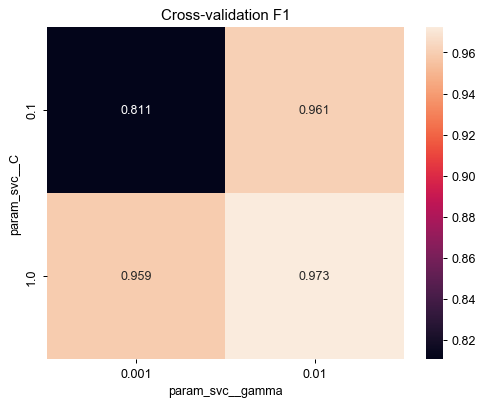

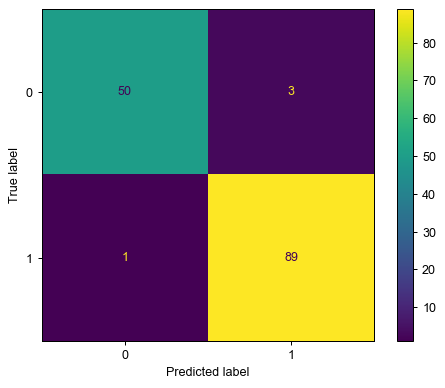

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
pipeline = make_pipeline(StandardScaler(), SVC())
param_grid = {'svc__C': [0.1, 1], 'svc__gamma': [0.001, 0.01]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=1,
                      error_score='raise', return_train_score=True)
search.fit(X_train, y_train)
print('最佳参数:', search.best_params_)
print('训练数据内部的最佳交叉验证 F1:', search.best_score_)
print(classification_report(y_test, search.predict(X_test)))
results = pd.DataFrame(search.cv_results_)
heat = results.pivot(index='param_svc__C', columns='param_svc__gamma', values='mean_test_score')
sns.heatmap(heat, annot=True, fmt='.3f'); plt.title('Cross-validation F1'); plt.show()
ConfusionMatrixDisplay.from_estimator(search, X_test, y_test); plt.show()